# OCR – Optičko prepoznavanje karaktera (OCR) 

## Šta je OCR?

*OCR* je skup metoda za pretvaranje slike teksta u mašinski čitljiv tekst.
U ovom projektu fokusiramo se na rukom pisane cifre (0–9), kao prvi korak ka širem OCR sistemu.

Ciljevi -> pravimo bazni OCR model za cifre 0–9:
- učitavanje i priprema MNIST podataka,
- vizuelni pregled uzoraka,
- CNN model i trening,
- evaluacija (accuracy, konfuziona matrica),
- Top-K verovatnoće (analiza grešaka),
- čuvanje/učitavanje modela,
- (opc.) osnova za segmentaciju niza cifara.

Ovo je polazna tačka za prelazak na EMNIST i realne slike iz aplikacije.

Zadatak: data je siva slika dimenzije 28×28 piksela → potrebno je predvideti kojoj klasi (cifri) pripada.
To je problem klasifikacije sa 10 klasa.

In [ ]:
import sys, pathlib, os
import datetime
import importlib
import src.ocr.eval.plot_training as pt
import cv2
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import matplotlib.pyplot as plt
import matplotlib.image as mpimg


from src.ocr.data.mnist import load_mnist
from src.ocr.models.cnn import build_cnn
from keras.optimizers import Adam  
from keras.callbacks import EarlyStopping, ModelCheckpoint, TensorBoard, CSVLogger, ReduceLROnPlateau
from pathlib import Path
from src.ocr.pipeline import predict_line_from_array, _segment_boxes,predict_line_string_from_array



### Provera okruženja
Proveravamo verzije i da li je GPU dostupan (nije obavezno, ali je korisno).

---

In [120]:

def find_project_root(marker="src", max_up=6):
    p = pathlib.Path.cwd()
    for _ in range(max_up):
        if (p / marker).exists():
            return p
        p = p.parent
    return None

PROJECT_ROOT = find_project_root("src")
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print("PROJECT_ROOT =", PROJECT_ROOT)
print("Postoji src? ", (PROJECT_ROOT / "src").exists())
print("sys.path[0]  =", sys.path[0])

PROJECT_ROOT = c:\Users\teani\Desktop\OCR
Postoji src?  True
sys.path[0]  = c:\Users\teani\Desktop\OCR


### Učitavanje i priprema MNIST podataka
Učitavamo MNIST, delimo train→train/val, normalizujemo u [0,1] i dodajemo kanal (28×28×1).

---

In [121]:

(X_train, y_train), (X_val, y_val), (X_test, y_test) = load_mnist()

print("Shapes:")
print("Train:", X_train.shape, y_train.shape)
print("Val:  ", X_val.shape, y_val.shape)
print("Test: ", X_test.shape, y_test.shape)


Shapes:
Train: (54000, 28, 28, 1) (54000,)
Val:   (6000, 28, 28, 1) (6000,)
Test:  (10000, 28, 28, 1) (10000,)


### Vizuelizacija uzoraka
Brzo proveravamo slike i labele da vidimo da li su podaci korektni.

---

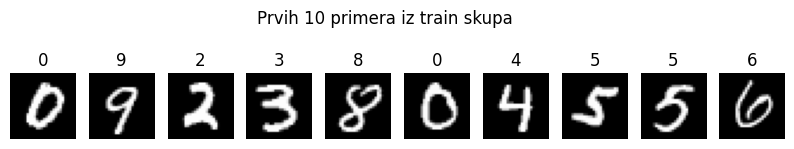

In [122]:
plt.figure(figsize=(10, 2))
for i in range(10):
    plt.subplot(1, 10, i + 1)
    plt.imshow(X_train[i].squeeze(), cmap="gray")
    plt.title(int(y_train[i]))
    plt.axis("off")
plt.suptitle("Prvih 10 primera iz train skupa")
plt.show()

### Definisanje CNN modela

Koristimo funkciju `build_cnn` iz `src/models/cnn.py`.  
Model sadrži:
- sloj za data augmentation (rotacija, translacija, zumiranje, šum),
- 3 konvolutivna bloka (Conv2D + MaxPooling),
- regularizaciju pomoću Dropout-a,
- Dense sloj sa 128 neurona,
- izlazni sloj sa softmax aktivacijom (10 klasa).

Ovo je arhitektura specijalno prilagođena za prepoznavanje rukom pisanih cifara (MNIST).

---

In [123]:

model = build_cnn()
model.compile(optimizer=Adam(),
              loss="sparse_categorical_crossentropy",
              metrics=["accuracy"])
model.summary()

Model: "mnist_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)      │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 7, 7, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │       802,944 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 896,906 (3.42 MB)

 Trainable params: 896,906 (3.42 MB)

 Non-trainable params: 0 (0.00 B)

### Trening + logovanje (EarlyStopping, Checkpoint, TensorBoard, CSVLogger)

Treniramo CNN i logujemo metrike u artifacts/training_log.csv. Čuvamo najbolji model po val_accuracy.

---

In [124]:


ARTIFACTS = Path(PROJECT_ROOT) / "artifacts"
ARTIFACTS.mkdir(exist_ok=True)

checkpoint_path = ARTIFACTS / "mnist_cnn_best.keras"
log_dir        = ARTIFACTS / "logs" / datetime.datetime.now().strftime("%Y%m%d-%H%M%S")
csv_path       = ARTIFACTS / "training_log.csv"

callbacks = [
    EarlyStopping(monitor="val_accuracy", patience=5, restore_best_weights=True),
    ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=2, verbose=1),
    ModelCheckpoint(str(checkpoint_path), monitor="val_accuracy", save_best_only=True, verbose=1),
    TensorBoard(log_dir=str(log_dir)),
    CSVLogger(str(csv_path)),   
]

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=5,              # epohe mogu da se povecaju/smanje
    batch_size=128,
    callbacks=callbacks,
    verbose=2
)

print("CSV log:", csv_path)
print("Best model:", checkpoint_path)

Epoch 1/5

Epoch 1: val_accuracy improved from None to 0.97833, saving model to c:\Users\teani\Desktop\OCR\artifacts\mnist_cnn_best.keras
422/422 - 26s - 61ms/step - accuracy: 0.9461 - loss: 0.1739 - val_accuracy: 0.9783 - val_loss: 0.0692 - learning_rate: 1.0000e-03
Epoch 2/5

Epoch 2: val_accuracy improved from 0.97833 to 0.98483, saving model to c:\Users\teani\Desktop\OCR\artifacts\mnist_cnn_best.keras
422/422 - 24s - 56ms/step - accuracy: 0.9848 - loss: 0.0495 - val_accuracy: 0.9848 - val_loss: 0.0499 - learning_rate: 1.0000e-03
Epoch 3/5

Epoch 3: val_accuracy improved from 0.98483 to 0.98700, saving model to c:\Users\teani\Desktop\OCR\artifacts\mnist_cnn_best.keras
422/422 - 21s - 49ms/step - accuracy: 0.9888 - loss: 0.0344 - val_accuracy: 0.9870 - val_loss: 0.0475 - learning_rate: 1.0000e-03
Epoch 4/5

Epoch 4: val_accuracy improved from 0.98700 to 0.98900, saving model to c:\Users\teani\Desktop\OCR\artifacts\mnist_cnn_best.keras
422/422 - 23s - 55ms/step - accuracy: 0.9918 - lo

### 📈 Vizuelizacija treninga po epohama

Na osnovu CSV log fajla (`training_log.csv`) prikazujemo promene **tačnosti (accuracy)** i **gubitka (loss)** tokom epoha.

Koristimo skriptu `plot_training.py` iz modula `src/ocr/eval/`:

- `accuracy_curve.png` — prikazuje rast tačnosti na *train* i *validation* skupovima,  
- `loss_curve.png` — prikazuje smanjenje gubitka tokom treniranja.
---

Saved: c:\Users\teani\Desktop\OCR\artifacts\accuracy_curve.png, c:\Users\teani\Desktop\OCR\artifacts\loss_curve.png
Final metrics -> acc:0.9933 | val_acc:0.9907 | loss:0.0216 | val_loss:0.0358 | lr:0.0010


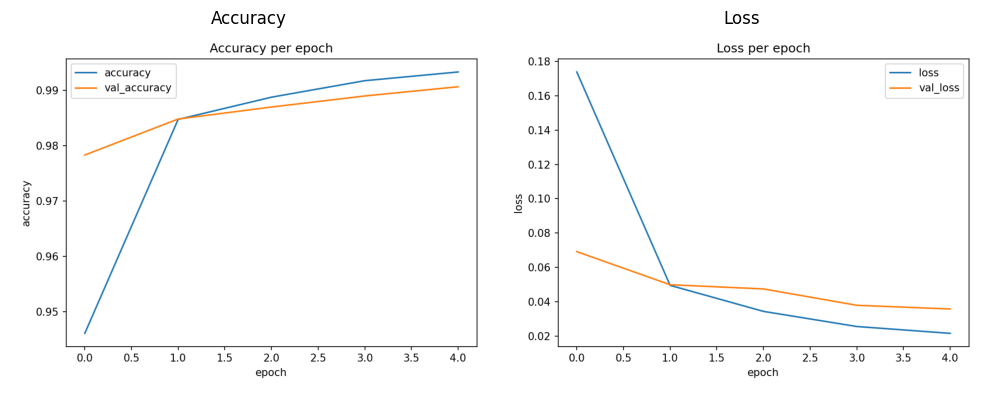

In [125]:
importlib.reload(pt)

pt.CSV_PATH = str(PROJECT_ROOT / "artifacts" / "training_log.csv")
pt.OUT_ACC  = str(PROJECT_ROOT / "artifacts" / "accuracy_curve.png")
pt.OUT_LOSS = str(PROJECT_ROOT / "artifacts" / "loss_curve.png")

pt.main()

fig, axes = plt.subplots(1, 2, figsize=(10, 4))  # širina i visina figure
for ax, path, title in zip(axes, [pt.OUT_ACC, pt.OUT_LOSS], ["Accuracy", "Loss"]):
    img = mpimg.imread(path)
    ax.imshow(img)
    ax.axis("off")
    ax.set_title(title, fontsize=12)

plt.tight_layout()
plt.show()


### 📊 Analiza rezultata treniranja

Na sledećim grafikonima prikazane su promene **tačnosti (accuracy)** i **gubitka (loss)** tokom epoha.  
Ovi grafici služe da vizuelno prikažu proces učenja modela i procenu njegove sposobnosti generalizacije.

#### 🔹 Accuracy (levo)
- Plava linija (`accuracy`) prikazuje tačnost modela na *trening skupu*.  
- Narandžasta linija (`val_accuracy`) prikazuje tačnost na *validacionom skupu*.  
- Oba grafikona rastu i stabilizuju se iznad **98–99%**, što znači da se model dobro prilagodio i uspešno generalizuje.  
- Pošto su linije blizu jedna drugoj, nema znaka **overfitting-a**.

#### 🔹 Loss (desno)
- Prikazuje smanjenje funkcije gubitka tokom epoha.  
- Gubitak na trening i validacionom skupu opada paralelno, što ukazuje na **stabilnu konvergenciju** modela.  
- Završne vrednosti su veoma niske (`loss ≈ 0.02`, `val_loss ≈ 0.038`).

#### ✅ Zaključak
Model je uspešno naučio da prepoznaje rukom pisane cifre (MNIST) sa **vrlo visokom tačnošću (~99%)**  
i bez primetnog prenaučavanja (overfitting-a).

---

### Konfuziona matrica
Gde model najviše greši (npr. 6 ↔ 5). 

---

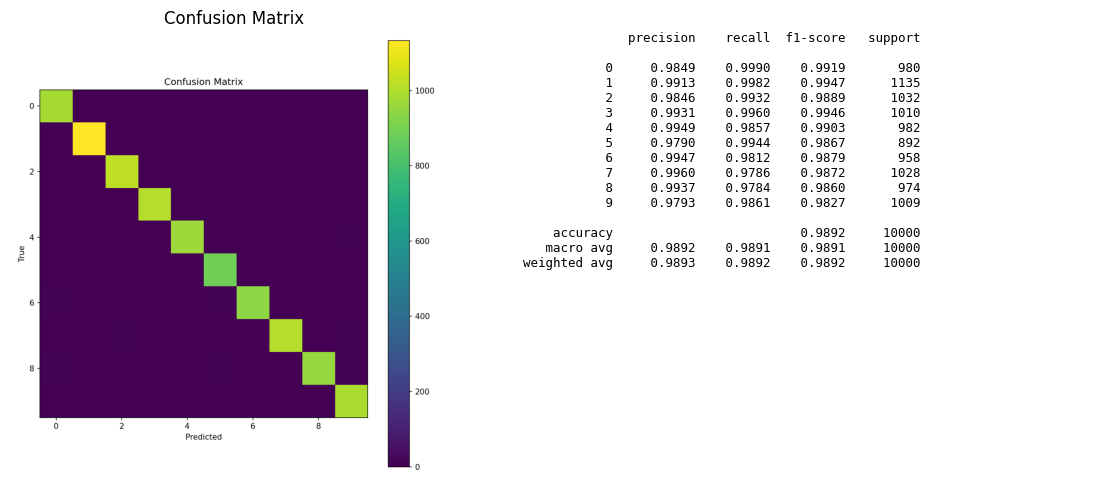

In [126]:
artifacts = PROJECT_ROOT / "artifacts"
cm_png = artifacts / "confusion_matrix.png"
report_txt = artifacts / "classification_report.txt"

img = mpimg.imread(cm_png)
report = report_txt.read_text(encoding="utf-8")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].imshow(img)
axes[0].axis("off")
axes[0].set_title("Confusion Matrix", fontsize=12)

axes[1].axis("off")
axes[1].text(0, 1, report, fontsize=9, family='monospace', va='top')

plt.tight_layout()
plt.show()


### 📊 Konfuziona matrica i evaluacija modela

Konfuziona matrica prikazuje kako model klasifikuje svaku cifru iz test skupa.  
Dijagonala predstavlja **tačne predikcije**, dok elementi van dijagonale pokazuju **greške modela**  
(npr. ako model često meša 6 ↔ 5, to bi se videlo kao jače obojeno polje van dijagonale).

Model je testiran na **10 000 uzoraka**, a rezultati pokazuju izuzetno visoku tačnost.

#### 🔹 Analiza rezultata:
- **Ukupna tačnost (accuracy):** `98.92 %`
- **Prosečni f1-score:** `~0.989`
- **Precision i recall** su stabilni kroz sve klase (0–9), bez značajnih odstupanja.
- **Nema dominantnih pogrešnih klasifikacija**, što znači da model prepoznaje i slične cifre (npr. 3↔8, 4↔9) sa visokim uspehom.

#### 🔹 Zaključak:
- Dijagonala matrice je gotovo potpuno popunjena — **model gotovo uvek pogodi tačnu cifru**.  
- Blage greške mogu se pojaviti kod cifara sličnog oblika (npr. 5 i 6, 8 i 9), ali su **statistički zanemarljive**.  
- Model pokazuje **stabilnost, visoku preciznost i odličnu generalizaciju** na neviđenim podacima.

📁 Svi rezultati (PNG i CSV fajlovi) sačuvani su u folderu `artifacts/`.

---

### 🔍 Pogrešno klasifikovani uzorci

Na sledećoj slici prikazani su **prvih 25 primera** koje model nije tačno klasifikovao iz test skupa.  
Svaka ćelija sadrži originalnu sliku sa oznakom:
- **T:** tačna oznaka (True label)  
- **P:** oznaka koju je model predvideo (Predicted label)

Ovakva vizualizacija pomaže da se uoče obrasci grešaka — npr. model može da meša cifre **5 i 6** ili **3 i 8**,  
što su vizuelno slične klase u MNIST skupu.

---

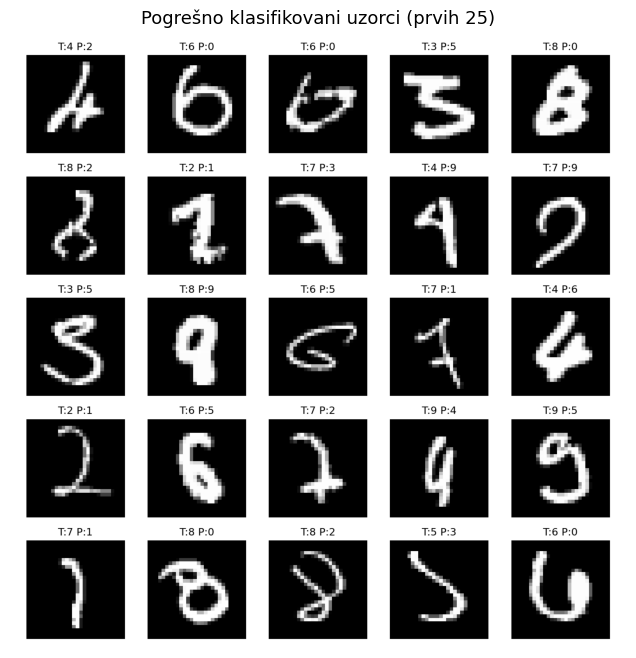

In [127]:
miss_png = artifacts / "misclassified_samples.png"

if miss_png.exists():
    img = mpimg.imread(miss_png)
    plt.figure(figsize=(8, 8))
    plt.imshow(img)
    plt.axis("off")
    plt.title("Pogrešno klasifikovani uzorci (prvih 25)", fontsize=13)
    plt.show()

### 🔍 Testiranje modela na sopstvenim uzorcima

U ovoj fazi proveravamo kako se trenirani model ponaša na **ručno pripremljenim slikama cifara** (van MNIST skupa).  
Slika se učitava iz foldera `samples/`, prikazuje se, a zatim se koristi funkcija `predict_line_from_array()`  
da bi se dobila predikcija svake segmentisane cifre.

---

📘 Ovi rezultati potvrđuju da model vrlo precizno prepoznaje rukom pisane cifre — čak i izvan originalnog MNIST skupa.


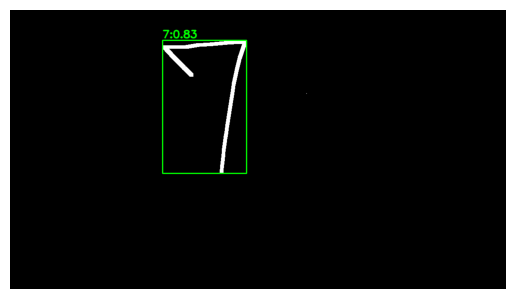

Top-1 cifra: 7 (conf=0.8333)


In [128]:

img_path = PROJECT_ROOT / "samples" / "sedam.png"
img = cv2.imread(str(img_path))  

preds = predict_line_from_array(img)          
boxes = _segment_boxes(cv2.cvtColor(img, cv2.COLOR_BGR2GRAY))  


i = int(np.argmax([c for _, c in preds]))      
lab, conf = preds[i]
x, y, w, h = boxes[min(i, len(boxes)-1)]       

vis = img.copy()
cv2.rectangle(vis, (x, y), (x+w, y+h), (0, 255, 0), 2)
cv2.putText(vis, f"{lab if isinstance(lab,int) else '?'}:{conf:.2f}",
            (x, max(0, y-6)), cv2.FONT_HERSHEY_SIMPLEX, 0.8, (0,255,0), 2, cv2.LINE_AA)

plt.imshow(cv2.cvtColor(vis, cv2.COLOR_BGR2RGB)); plt.axis("off"); plt.show()
print(f"Top-1 cifra: {lab} (conf={conf:.4f})")



Predikcija niza (cifre): 2557116

Confidence po cifri (sleva nadesno):
1. 2  —  0.912
2. 5  —  0.999
3. 5  —  1.000
4. 7  —  0.951
5. 1  —  0.993
6. 1  —  0.994
7. 6  —  0.936


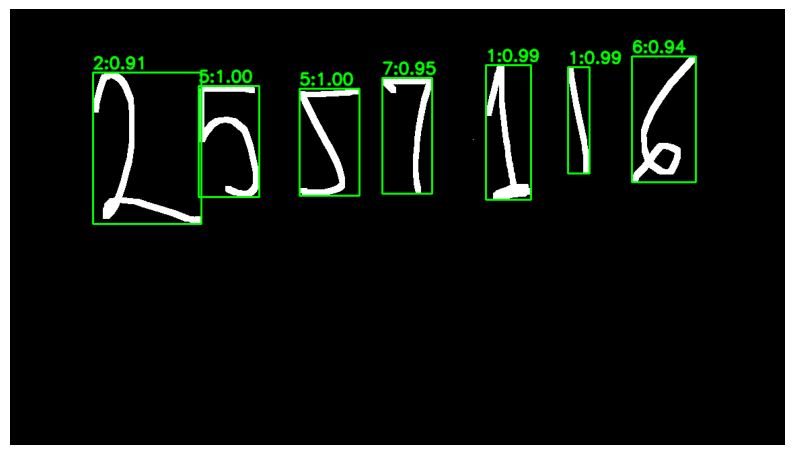

In [129]:

img_path = PROJECT_ROOT / "samples" / "2557116.png"
img = cv2.imread(str(img_path))  

preds = predict_line_from_array(img)   

out_str=predict_line_string_from_array(img)
print(f"Predikcija niza (cifre): {out_str}\n")

print("Confidence po cifri (sleva nadesno):")
for i, (lab, conf) in enumerate(preds, 1):
    print(f"{i}. {lab}  —  {conf:.3f}")

gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
boxes = _segment_boxes(gray)  

vis = img.copy()
for (x, y, w, h), (lab, conf) in zip(boxes, preds):
    cv2.rectangle(vis, (x, y), (x + w, y + h), (0, 255, 0), 2)
    cv2.putText(vis, f"{lab if isinstance(lab,int) else '?'}:{conf:.2f}",
                (x, max(0, y - 6)), cv2.FONT_HERSHEY_SIMPLEX, 0.8,
                (0, 255, 0), 2, cv2.LINE_AA)

plt.figure(figsize=(10, 6))
plt.imshow(cv2.cvtColor(vis, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()
